## 📌 Carga de datos y generación de features iniciales

**Objetivo:**  
Preparar el dataset para el análisis exploratorio mediante la carga de datos y la generación de variables derivadas relevantes.

**Descripción:**  
Se carga el dataset desde un archivo CSV previamente obtenido mediante la API de NOAA.  
Posteriormente, se aplican funciones de preprocesamiento definidas en un módulo externo (`src/preprocessing.py`) con el objetivo de enriquecer el dataset.

Las transformaciones realizadas incluyen:

- **Features temporales:**
  - Año (`YEAR`)
  - Mes (`MONTH`)
  - Día (`DAY`)

- **Variables objetivo (targets):**
  - Indicador de lluvia (`RAIN`)
  - Indicador de nieve (`SNOW_DAY`)

**Resultados / Insights:**  
La incorporación de estas variables permite:
- Facilitar análisis temporales (estacionalidad, tendencias)
- Reducir la complejidad al resumir información climática (ej: temperatura media)
- Preparar el dataset para futuros modelos de clasificación (lluvia/nieve)

Además, la modularización del preprocesamiento mejora la reutilización del código y la escalabilidad del proyecto.

## 📌 Consideraciones sobre el flujo de trabajo

Durante el desarrollo del EDA, se identificó la importancia de separar claramente:

- Dataset original (`df_raw`)
- Dataset procesado (`df`)

Esto permite:
- Evitar la pérdida de información original
- Garantizar reproducibilidad
- Facilitar debugging y validación de transformaciones

A partir de este punto, todas las transformaciones se aplican sobre una copia del dataset original.

In [3]:
import pandas as pd

df_raw = pd.read_csv("../data/raw/ghcn_daily_data.csv", parse_dates=["DATE"])
df = df_raw.copy()

import sys
import os
import pandas as pd

sys.path.append(os.path.abspath("../src"))

from preprocessing import (
    add_time_features,
    add_temperature_features,
    create_rain_target,
    create_snow_target
)

df = add_time_features(df)
df = add_temperature_features(df)
df = create_rain_target(df)
df = create_snow_target(df)
df.head()

,DATE,AWND,STATION,SNOW,LONGITUDE,TMAX,ELEVATION,TMIN,PRCP,LATITUDE,YEAR,MONTH,DAY,TEMP_MEAN,TEMP_RANGE,RAIN,SNOW_DAY
0,2020-01-01,2.8,USW00014607,13.0,-68.01723,-1.0,188.6,-5.5,1.0,46.87049,2020,1,1,-3.25,4.5,1,1
1,2020-01-02,2.4,USW00014607,0.0,-68.01723,0.6,188.6,-5.5,0.0,46.87049,2020,1,2,-2.45,6.1,0,0
2,2020-01-03,1.8,USW00014607,3.0,-68.01723,3.3,188.6,-4.3,0.0,46.87049,2020,1,3,-0.50,7.6,0,1
3,2020-01-04,2.0,USW00014607,0.0,-68.01723,2.8,188.6,-2.1,0.0,46.87049,2020,1,4,0.35,4.9,0,0
4,2020-01-05,5.6,USW00014607,18.0,-68.01723,-1.6,188.6,-9.3,1.3,46.87049,2020,1,5,-5.45,7.7,1,1


## 📌 Estructura y estadísticas descriptivas del dataset

**Objetivo:**  
Analizar la estructura general del dataset, los tipos de datos y obtener un resumen estadístico de las variables numéricas.

**Descripción:**  
Se utiliza `df.info()` para inspeccionar:
- Tipos de datos
- Cantidad de valores no nulos
- Consumo de memoria

Y `df.describe()` para obtener estadísticas descriptivas como:
- Media
- Desvío estándar
- Cuartiles
- Valores mínimos y máximos

**Resultados / Insights:**

- El dataset contiene **2192 registros y 14 variables**, con una estructura consistente para análisis.
  
- **Valores faltantes:**
  - La mayoría de las variables no presentan valores nulos.
  - La variable `AWND` presenta una leve cantidad de valores faltantes (~8 registros), lo cual deberá tratarse en etapas posteriores.

- **Tipos de datos:**
  - Variables temporales correctamente tipadas (`datetime`)
  - Variables numéricas en formato adecuado (`float` / `int`)
  - `STATION` como variable categórica

- **Distribuciones relevantes:**
  - `PRCP` y `SNOW` presentan distribuciones altamente sesgadas (muchos ceros), lo cual es esperable en datos climáticos.
  - `TEMP_MEAN` muestra valores negativos y positivos, indicando variabilidad térmica significativa a lo largo del año.
  - `TEMP_RANGE` evidencia amplitudes térmicas variables, lo que puede ser relevante para análisis estacional.

- **Variables objetivo:**
  - `RAIN` y `SNOW_DAY` son variables binarias con clases desbalanceadas, lo cual será importante considerar en futuros modelos.

**Conclusión:**  
El dataset presenta buena calidad estructural y es apto para continuar con el análisis exploratorio, requiriendo únicamente un tratamiento menor de valores faltantes.

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DATE        2192 non-null   datetime64[ns]
 1   AWND        2184 non-null   float64       
 2   STATION     2192 non-null   object        
 3   SNOW        2192 non-null   float64       
 4   LONGITUDE   2192 non-null   float64       
 5   TMAX        2192 non-null   float64       
 6   ELEVATION   2192 non-null   float64       
 7   TMIN        2192 non-null   float64       
 8   PRCP        2192 non-null   float64       
 9   LATITUDE    2192 non-null   float64       
 10  YEAR        2192 non-null   int32         
 11  MONTH       2192 non-null   int32         
 12  DAY         2192 non-null   int32         
 13  TEMP_MEAN   2192 non-null   float64       
 14  TEMP_RANGE  2192 non-null   float64       
 15  RAIN        2192 non-null   int64         
 16  SNOW_DAY    2192 non-nul

,DATE,AWND,SNOW,LONGITUDE,TMAX,ELEVATION,TMIN,PRCP,LATITUDE,YEAR,MONTH,DAY,TEMP_MEAN,TEMP_RANGE,RAIN,SNOW_DAY
count,2192,2184.000000,2192.000000,2.192000e+03,2192.000000,2.192000e+03,2192.000000,2192.000000,2.192000e+03,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000
mean,2022-12-31 12:00:00,3.122299,8.189325,-6.801723e+01,11.445027,1.886000e+02,0.740511,2.711314,4.687049e+01,2022.499544,6.521898,15.732664,6.092769,10.704516,0.431113,0.185675
min,2020-01-01 00:00:00,0.200000,0.000000,-6.801723e+01,-18.800000,1.886000e+02,-34.300000,0.000000,4.687049e+01,2020.000000,1.000000,1.000000,-24.050000,1.000000,0.000000,0.000000
25%,2021-07-01 18:00:00,2.100000,0.000000,-6.801723e+01,1.100000,1.886000e+02,-6.600000,0.000000,4.687049e+01,2021.000000,4.000000,8.000000,-2.450000,7.200000,0.000000,0.000000
50%,2022-12-31 12:00:00,3.000000,0.000000,-6.801723e+01,12.200000,1.886000e+02,1.100000,0.000000,4.687049e+01,2022.500000,7.000000,16.000000,6.700000,10.500000,0.000000,0.000000
75%,2024-07-01 06:00:00,3.900000,0.000000,-6.801723e+01,21.700000,1.886000e+02,10.000000,2.000000,4.687049e+01,2024.000000,10.000000,23.000000,15.800000,13.900000,1.000000,0.000000
max,2025-12-31 00:00:00,9.500000,356.000000,-6.801723e+01,35.600000,1.886000e+02,21.700000,50.800000,4.687049e+01,2025.000000,12.000000,31.000000,28.650000,25.400000,1.000000,1.000000
std,NaN,1.396748,31.426807,1.705692e-12,11.947327,5.913064e-12,11.072157,6.149111,9.239163e-13,1.708571,3.449773,8.803378,11.293564,4.525953,0.495345,0.388933


## 📌 Análisis de valores faltantes

**Objetivo:**  
Identificar la presencia y magnitud de valores faltantes en el dataset.

**Descripción:**  
Se calcula la cantidad de valores nulos por variable para evaluar la necesidad de tratamiento.

**Resultados / Insights:**

- La mayoría de las variables no presentan valores faltantes.
- La variable `AWND` presenta una pequeña cantidad de valores nulos.

Dado que la proporción de valores faltantes es baja, se consideraron estrategias simples como:
- Eliminación de registros
- Imputación con medidas estadísticas (media/mediana)

**Conclusión:**  
Los valores faltantes no representan un problema significativo para el análisis y pueden ser tratados sin impacto relevante en la calidad del dataset.
Entre ambas estrategias planteadas se opto por la eliminación de los registros.

**Validación:**  
Se verifica que no queden valores faltantes tras el preprocesamiento.

### 🔎 Análisis de consistencia temporal

**Objetivo:**  
Verificar si los valores faltantes en el dataset están asociados a interrupciones en la recolección de datos.

**Descripción:**  
Se analiza el rango temporal del dataset y la cantidad de registros por año, esperando aproximadamente 365 (o 366 en años bisiestos) observaciones anuales.

**Resultados / Insights:**

- El dataset presenta una cobertura temporal continua, con:
  - 365 registros en años normales
  - 366 registros en años bisiestos

- Esto indica que **no existen días faltantes en la serie temporal**, es decir, no hay interrupciones en la recolección de datos.

**Conclusión:**  
Los valores faltantes observados (por ejemplo en `AWND`) **no se deben a ausencia de registros diarios**, sino a mediciones específicas no registradas o incompletas.

Esto sugiere que el tratamiento de nulos debe enfocarse a nivel de variable y no a nivel de eliminación de fechas.

In [10]:
from IPython.display import display

# Verificar valores nulos
display(df.isnull().sum())

#Analisis de consistencia temporal
display(df["YEAR"].value_counts().sort_index())

DATE          0
AWND          8
STATION       0
SNOW          0
LONGITUDE     0
TMAX          0
ELEVATION     0
TMIN          0
PRCP          0
LATITUDE      0
YEAR          0
MONTH         0
DAY           0
TEMP_MEAN     0
TEMP_RANGE    0
RAIN          0
SNOW_DAY      0
dtype: int64

YEAR
2020    366
2021    365
2022    365
2023    365
2024    366
2025    365
Name: count, dtype: int64

## 📌 Tratamiento de valores faltantes

**Objetivo:**  
Imputar valores faltantes en la variable `AWND` sin afectar la distribución general del dataset.

**Descripción:**  
Se opta por imputar los valores faltantes utilizando la **mediana** de la variable.

**Justificación:**

- La mediana es robusta frente a valores extremos, los cuales son frecuentes en variables climáticas como la velocidad del viento (por ejemplo, durante tormentas).
- Permite preservar la distribución original de los datos sin introducir sesgos significativos.
- Se evita la eliminación de registros, lo cual es importante para no perder información asociada a otras variables relevantes (como precipitaciones o nieve).

**Conclusión:**  
La imputación mediante mediana resulta adecuada para este caso, manteniendo la integridad del dataset y minimizando el impacto de valores atípicos.

In [16]:
median_value = df["AWND"].median()
df["AWND"] = df["AWND"].fillna(median_value)

# Verificacion de valores nulos despues de la imputacion
display(df.isnull().sum())

DATE          0
AWND          0
STATION       0
SNOW          0
LONGITUDE     0
TMAX          0
ELEVATION     0
TMIN          0
PRCP          0
LATITUDE      0
YEAR          0
MONTH         0
DAY           0
TEMP_MEAN     0
TEMP_RANGE    0
RAIN          0
SNOW_DAY      0
dtype: int64

## 📌 Análisis estacional de nieve y temperatura

**Objetivo:**  
Analizar la distribución mensual de la nieve y su relación con la temperatura media durante el año 2025.

**Descripción:**  
Se agrupan los datos por mes y se calcula:

- Acumulado mensual de nieve (`SNOW`)
- Temperatura media mensual (`TEMP_MEAN`)

Se visualiza mediante:
- Gráfico de barras → nieve acumulada
- Línea → temperatura media

**Resultados / Insights:**

- Se observa una **fuerte estacionalidad** en la nieve:
  - Altos valores en meses fríos (invierno)
  - Valores nulos o cercanos a cero en meses cálidos

- Existe una **relación inversa clara entre temperatura y nieve**:
  - A medida que aumenta la temperatura, la nieve disminuye significativamente
  - La nieve se concentra principalmente en temperaturas cercanas o inferiores a 0°C

- La transición entre estaciones (otoño/primavera) muestra una reducción progresiva de nieve, acompañada por el aumento de temperatura.

**Conclusión:**  
La nieve presenta un comportamiento altamente dependiente de la temperatura, lo cual valida la consistencia climática del dataset y sugiere que la temperatura es una variable clave para modelar eventos de nieve.
Se identifica un umbral térmico cercano a 0°C, por debajo del cual la probabilidad de acumulación de nieve aumenta considerablemente.

2025-01-01 00:00:00 2025-12-31 00:00:00


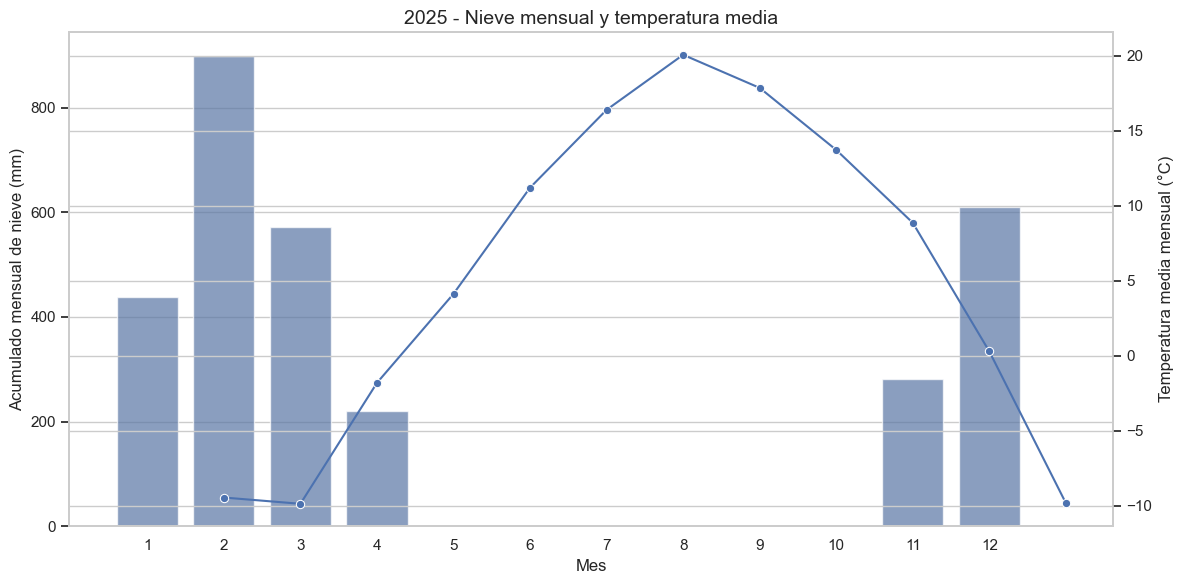

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analisis exploratorio: Acumulado mensual de nieve en 2025
df_year = df[df["DATE"].dt.year == 2025]
print(df_year["DATE"].min(), df_year["DATE"].max())

# Agrupar por mes y calcular el acumulado de nieve y la temperatura media
monthly_snow = (
    df_year
    .groupby("MONTH")
    .agg({
        "SNOW": "sum",
        "TEMP_MEAN": "mean"
    })
)

# Reindexar para asegurar que todos los meses estén presentes
monthly_snow = monthly_snow.reindex(range(1, 13))
monthly_snow = monthly_snow.reset_index()

sns.set_theme(style="whitegrid")

# --- Nieve (barras)
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=monthly_snow,
    x="MONTH",
    y="SNOW",
    ax=ax1,
    alpha=0.7
)

ax1.set_ylabel("Acumulado mensual de nieve (mm)", fontsize=12)
ax1.set_xlabel("Mes", fontsize=12)
ax1.set_title(f"{2025} - Nieve mensual y temperatura media", fontsize=14)

# --- Temperatura (línea)
ax2 = ax1.twinx()
sns.lineplot(
    data=monthly_snow,
    x="MONTH",
    y="TEMP_MEAN",
    marker="o",
    ax=ax2
)
ax2.set_ylabel("Temperatura media mensual (°C)", fontsize=12)

plt.tight_layout()
plt.show()


## 📌 Análisis estacional de lluvia y temperatura

**Objetivo:**  
Analizar la distribución mensual de la precipitación y su relación con la temperatura media.

**Descripción:**  
Se agrupan los datos por mes y se calcula:

- Precipitación total mensual (`PRCP`)
- Temperatura media mensual (`TEMP_MEAN`)

Se visualiza mediante:
- Barras → lluvia acumulada
- Línea → temperatura media

**Resultados / Insights:**

- La lluvia presenta una distribución más homogénea a lo largo del año en comparación con la nieve.
- No se observa una relación directa o lineal entre temperatura y precipitación.
- Existen meses con alta precipitación en rangos de temperatura diversos, lo que indica que la lluvia no depende exclusivamente de la temperatura.

**Conclusión:**  
A diferencia de la nieve, la lluvia es un fenómeno menos dependiente de la temperatura, lo que sugiere que otras variables (como humedad o presión atmosférica) podrían ser relevantes para su modelado.

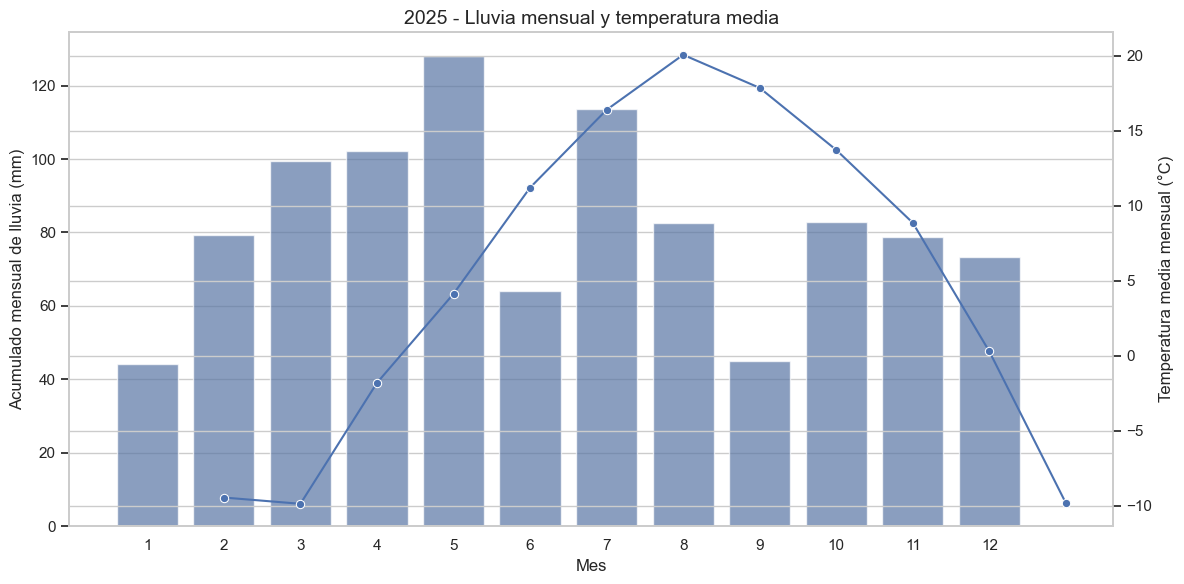

In [23]:
# Agrupar por mes: lluvia + temperatura
monthly_rain = (
    df_year
    .groupby("MONTH")
    .agg({
        "PRCP": "sum",
        "TEMP_MEAN": "mean"
    })
)

# Reindexar meses
monthly_rain = monthly_rain.reindex(range(1, 13)).reset_index()

sns.set_theme(style="whitegrid")

# --- Lluvia (barras)
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=monthly_rain,
    x="MONTH",
    y="PRCP",
    ax=ax1,
    alpha=0.7
)

ax1.set_ylabel("Acumulado mensual de lluvia (mm)", fontsize=12)
ax1.set_xlabel("Mes", fontsize=12)
ax1.set_title("2025 - Lluvia mensual y temperatura media", fontsize=14)

# --- Temperatura (línea)
ax2 = ax1.twinx()

sns.lineplot(
    data=monthly_rain,
    x="MONTH",
    y="TEMP_MEAN",
    marker="o",
    ax=ax2
)

ax2.set_ylabel("Temperatura media mensual (°C)", fontsize=12)

plt.tight_layout()
plt.show()

In [19]:
df["RAIN"].value_counts(normalize=True)
# La proporcion de días con lluvia es aproximadamente 43.1%, lo que indica que la lluvia es un evento relativamente común en el conjunto de datos.

RAIN
0    0.568887
1    0.431113
Name: proportion, dtype: float64

## 📌 Análisis de correlaciones entre variables climáticas

**Objetivo:**  
Identificar relaciones lineales entre variables relevantes del dataset.

**Resultados / Insights:**

- Se observa una **correlación negativa entre temperatura media y nieve**, lo cual es consistente con el comportamiento esperado. Sin embargo, la magnitud moderada sugiere una relación no estrictamente lineal.
- Existe una **correlación positiva entre precipitación (`PRCP`) y nieve (`SNOW`)**, indicando que parte de los eventos de precipitación ocurren en forma de nieve, dependiendo de las condiciones térmicas.
- La **correlación negativa entre rango térmico (`TEMP_RANGE`) y precipitación** sugiere que los días con lluvia tienden a presentar menor variabilidad de temperatura, posiblemente debido a condiciones de nubosidad.
- La variable de velocidad del viento (`AWND`) no presenta correlaciones significativas con otras variables.

**Conclusión:**  
Las correlaciones reflejan relaciones climáticas coherentes, destacándose la influencia de la temperatura sobre la nieve y la naturaleza más compleja de la precipitación.

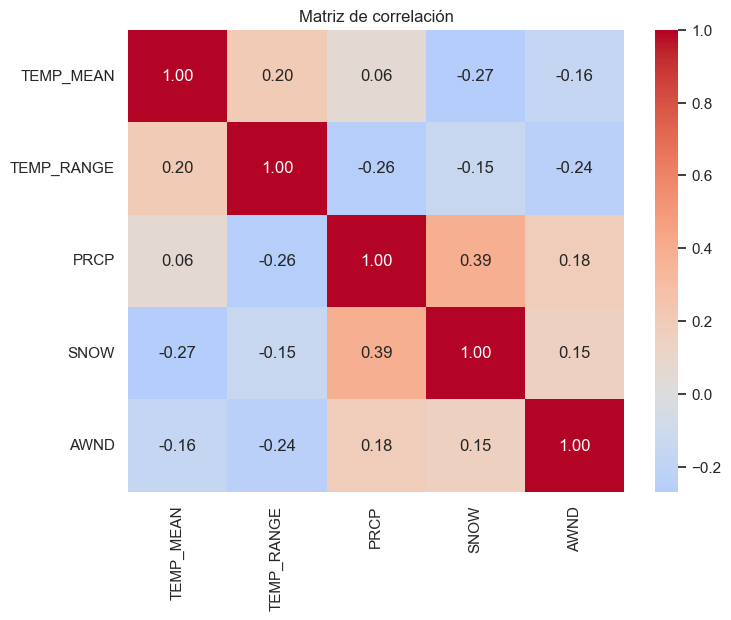

In [24]:
# Seleccionar variables numéricas relevantes
cols = ["TEMP_MEAN", "TEMP_RANGE", "PRCP", "SNOW", "AWND"]

corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")

plt.show()

## 📌 Analisis bi-variable en Scatter plot


### 🔎 Temperatura vs Nieve

Se observa un comportamiento no lineal con una fuerte concentración de valores de nieve en temperaturas bajas.

- Para temperaturas superiores a 0°C, la presencia de nieve es prácticamente nula.
- Por debajo de este umbral, la nieve aparece con alta variabilidad en su magnitud.

Esto sugiere la existencia de un **umbral térmico crítico**, más que una relación lineal directa.

### 🔎 Temperatura vs Precipitación

La relación entre temperatura y precipitación no presenta un patrón claro o lineal.

- La lluvia ocurre en un amplio rango de temperaturas.
- No se identifica un umbral térmico definido como en el caso de la nieve.
- Los eventos de precipitación intensa se distribuyen en distintos niveles térmicos.

**Conclusión:**  
A diferencia de la nieve, la precipitación es un fenómeno más complejo y probablemente dependiente de múltiples variables no incluidas en el dataset.

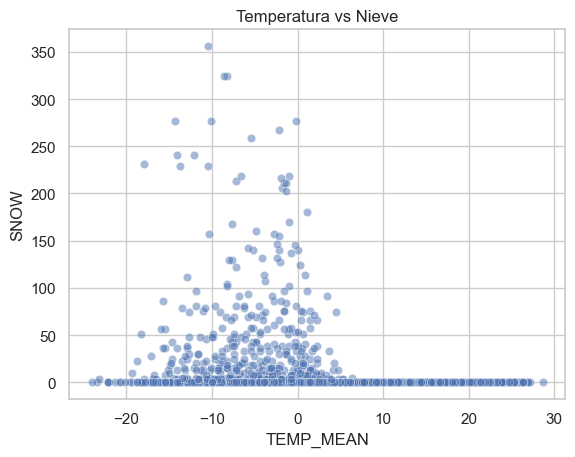

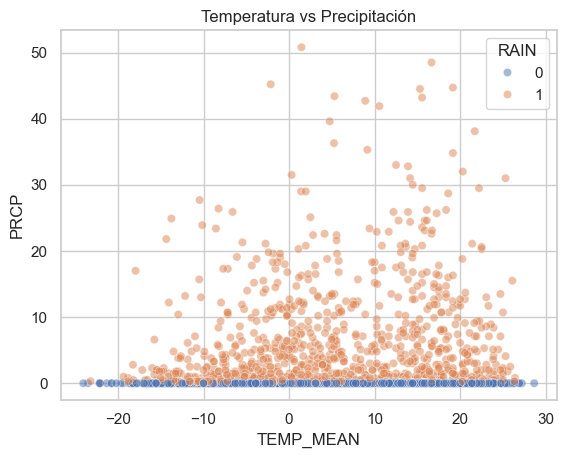

In [29]:
#Scatterplot: Temperatura vs Nieve
sns.scatterplot(data=df, x="TEMP_MEAN", y="SNOW", alpha=0.5)
plt.title("Temperatura vs Nieve")
plt.show()

#Scatterplot: Temperatura vs Precipitación, coloreado por lluvia
sns.scatterplot(
    data=df,
    x="TEMP_MEAN",
    y="PRCP",
    hue="RAIN",
    alpha=0.5
)
plt.title("Temperatura vs Precipitación")
plt.show()